# Spatial kinase perturbation QC

Comprehensive quality control and summary analysis of nine clean spatial kinase-perturbation slides.

**Analysis plan**
1. Read h5ad components directly with `h5py`, validating dimensions and categorical encodings.
2. Summarize cells, embryoid bodies (EBs), cell types, guides, and target genes.
3. Inspect EB-size distributions and spatial distributions by EB and cell type.
4. Estimate target-gene knockdown using Wilcoxon rank-sum tests for targets represented in at least 10 cells, with Benjamini–Hochberg false-discovery-rate correction.
5. Quantify perturbation frequency and target enrichment across annotated cell types.

**Key assumptions and limitations**
- Cells are treated as independent in rank-sum tests, although cells within EBs and slides may be correlated. P-values may therefore be anti-conservative.
- There is no non-targeting control (NTC). Each target-positive group is compared with cells lacking that target, restricted to slides where the gene is measured. The result is an association, not a causal estimate, and may be confounded by slide, EB, cell type, guide multiplicity, or perturbation-induced composition shifts.
- `X` is SCT-normalized, nonnegative expression. Log2 fold change is computed from arithmetic group means with a small fixed pseudocount (0.01 normalized-expression units).
- Cell-state summaries and enrichment analyses use `cell_type`; Seurat cluster labels are not used.


## Setup and optional download

In [1]:
from pathlib import Path
import os, sys, subprocess, warnings
import h5py
import numpy as np
import pandas as pd
from scipy import sparse, stats
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
mpl.rcParams.update({'figure.dpi': 90, 'savefig.dpi': 90, 'font.size': 9})

BASE = Path('/workspace/perturb-tags')
DATA = BASE / 'data'
SLIDES = {
    'slide1': ('slide1_clean_manual_EBs.h5ad', '1AkGK1U2ftbFhcu6XiUf-gtNe7Pljhm5C'),
    'slide2': ('slide2_clean_manual_EBs.h5ad', '1QfGzb959oAr0kDlI91tpWrKAyosTbMwJ'),
    'slide3': ('slide3_clean_manual_EBs.h5ad', '1wI8pwS9lO6TFF2ProIFY9Y7TTbfCG_e9'),
    'slide4': ('slide4_clean_manual_EBs.h5ad', '14j5E_Ec3SqSPeGHaUFaF5shqa__VIC0m'),
    'slide5': ('slide5_clean_manual_EBs.h5ad', '1NrnUbk3XH9gCoM8R9ZdXIrU9gbnYsvjF'),
    'slide6': ('slide6_clean_manual_EBs.h5ad', '1f8au2xk--Fm4MrsdMiS9sGvAyXQ0tL4x'),
    'slide7': ('slide7_clean_manual_EBs.h5ad', '1NKPB-bQc1OVrlMquCt-5a9P3vczpvPe2'),
    'slide8': ('slide8_clean_manual_EBs.h5ad', '1ZHhYHHIzOO22-zel0Pjv02aFrrKMWd8q'),
    'slide9': ('slide9_clean_manual_EBs.h5ad', '1mh9heUhWEo6UgIOWUtFdGa15r7L0Ipz7'),
}
DATA.mkdir(parents=True, exist_ok=True)
for slide, (filename, file_id) in SLIDES.items():
    path = DATA / filename
    if not path.exists():
        try:
            import gdown
        except ImportError:
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=True)
            import gdown
        print(f'Downloading {slide}...')
        gdown.download(id=file_id, output=str(path), quiet=False)
    assert path.exists() and path.stat().st_size > 0, f'Missing or empty: {path}'
print('All nine clean input files are available.')


All nine clean input files are available.


## 1. Data loading and summary statistics

In [2]:
def decode_array(x):
    a = np.asarray(x)
    if a.dtype.kind in 'SO':
        return np.array([v.decode('utf-8') if isinstance(v, (bytes, np.bytes_)) else str(v) for v in a], dtype=object)
    return a

def read_h5ad_vector(node):
    if isinstance(node, h5py.Group) and 'categories' in node and 'codes' in node:
        categories = decode_array(node['categories'][:])
        codes = node['codes'][:].astype(int)
        out = np.full(len(codes), None, dtype=object)
        valid = codes >= 0
        out[valid] = categories[codes[valid]]
        return out
    if isinstance(node, h5py.Dataset):
        return decode_array(node[:])
    raise TypeError(f'Unsupported h5ad vector node: {type(node)}')

def read_sparse(group):
    enc = group.attrs.get('encoding-type', '')
    if isinstance(enc, bytes): enc = enc.decode()
    shape = tuple(group.attrs['shape'])
    args = (group['data'][:], group['indices'][:], group['indptr'][:])
    if enc == 'csc_matrix': return sparse.csc_matrix(args, shape=shape)
    if enc == 'csr_matrix': return sparse.csr_matrix(args, shape=shape)
    raise ValueError(f'Unknown sparse encoding: {enc}')

def clean_guide_string(x):
    if x is None: return ''
    x = str(x).strip()
    return '' if x.lower() in {'', 'nan', 'none', 'na'} else x

def split_guides(x):
    return sorted(set(g.strip() for g in clean_guide_string(x).split('|') if g.strip()))

def guide_target(g):
    return g.rsplit('-', 1)[0] if '-' in g else g

obs_cols = ['EB_cluster_manual','cell_type','guides_passing_str','is_perturbed_any',
            'n_guides_passing','physical_slide']
frames, spatial, gene_names, schemas = [], {}, {}, []
for slide, (filename, _) in SLIDES.items():
    path = DATA / filename
    with h5py.File(path, 'r') as f:
        n, p = map(int, f['X'].attrs['shape'])
        d = {k: read_h5ad_vector(f['obs'][k]) for k in obs_cols}
        df = pd.DataFrame(d)
        assert len(df) == n and f['obsm']['X_spatial'].shape == (n, 2)
        df['slide'] = slide
        df['cell_id_within_slide'] = np.arange(n)
        df['guides_passing_str'] = df['guides_passing_str'].map(clean_guide_string)
        df['is_perturbed_any'] = df['is_perturbed_any'].astype(bool)
        df['guide_list'] = df['guides_passing_str'].map(split_guides)
        df['target_list'] = df['guide_list'].map(lambda z: sorted(set(guide_target(g) for g in z)))
        frames.append(df)
        spatial[slide] = f['obsm']['X_spatial'][:]
        gene_names[slide] = decode_array(f['var']['name'][:])
        schemas.append((slide, n, p, f['X'].attrs.get('encoding-type','unknown')))
obs = pd.concat(frames, ignore_index=True)
obs['EB_id'] = obs['slide'].astype(str) + '::' + obs['EB_cluster_manual'].astype(str)
print('Validated schemas (slide, cells, genes, X encoding):')
print(pd.DataFrame(schemas, columns=['slide','cells','genes','X_encoding']).to_string(index=False))
print(f'Combined observations: {len(obs):,} cells')
print(f"Guide flag/list disagreements: {(obs.is_perturbed_any != obs.guide_list.map(bool)).sum():,}")

Validated schemas (slide, cells, genes, X encoding):
 slide  cells  genes X_encoding
slide1   2585  19408 csc_matrix
slide2  11919  29172 csc_matrix
slide3   5220  26531 csc_matrix
slide4   3669  25565 csc_matrix
slide5   6312  26214 csr_matrix
slide6   7865  28048 csr_matrix
slide7   8140  27897 csr_matrix
slide8  17576  29978 csr_matrix
slide9   6946  22760 csr_matrix
Combined observations: 70,232 cells
Guide flag/list disagreements: 38,563


Slide summary


,total_cells,cells_with_sgRNA,sgRNA_fraction,EBs,cell_types
slide,,,,,
slide1,2585,1266,49.0%,98,4
slide2,11919,4291,36.0%,132,3
slide3,5220,2709,51.9%,133,4
slide4,3669,2029,55.3%,99,4
slide5,6312,3160,50.1%,45,4
slide6,7865,2834,36.0%,40,4
slide7,8140,4347,53.4%,34,5
slide8,17576,7341,41.8%,116,4
slide9,6946,3692,53.2%,74,5


Cells per cell type and slide


slide,slide1,slide2,slide3,slide4,slide5,slide6,slide7,slide8,slide9,Total
cell_type,,,,,,,,,,
Early Ectoderm,288,2156,1153,985,1844,1419,2699,1388,1761,13693
Endoderm,173,0,714,263,575,624,834,3300,782,7265
Mesoderm,0,0,0,0,0,0,12,0,0,12
Neural Crest,671,329,180,130,384,262,316,509,461,3242
Neurons,0,0,0,0,0,0,0,0,22,22
Pluripotent,1453,9434,3173,2291,3509,5560,4279,12379,3920,45998


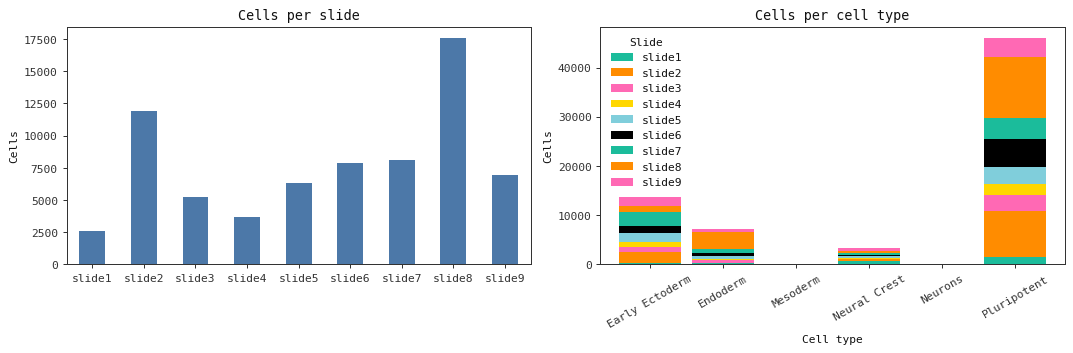

In [3]:
slide_summary = obs.groupby('slide', observed=True).agg(
    total_cells=('slide','size'),
    cells_with_sgRNA=('is_perturbed_any','sum'),
    sgRNA_fraction=('is_perturbed_any','mean'),
    EBs=('EB_cluster_manual','nunique'),
    cell_types=('cell_type','nunique')
)
slide_summary['sgRNA_fraction'] = slide_summary['sgRNA_fraction'].map(lambda x: f'{x:.1%}')
print('Slide summary')
display(slide_summary)
ct_counts = pd.crosstab(obs['cell_type'], obs['slide'])
print('Cells per cell type and slide')
display(ct_counts.assign(Total=ct_counts.sum(axis=1)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
obs['slide'].value_counts().reindex(SLIDES).plot.bar(ax=ax[0], color='#4C78A8')
ax[0].set(title='Cells per slide', xlabel='', ylabel='Cells'); ax[0].tick_params(axis='x', rotation=0)
ct_counts.plot.bar(stacked=True, ax=ax[1], width=.85)
ax[1].set(title='Cells per cell type', xlabel='Cell type', ylabel='Cells')
ax[1].legend(title='Slide', frameon=False)
ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


## 2. Embryoid body summary

EBs per slide:


,n_EBs
slide,
slide1,98
slide2,132
slide3,133
slide4,99
slide5,45
slide6,40
slide7,34
slide8,116
slide9,74


Cells per EB distribution by slide:


,count,mean,std,min,10%,25%,50%,75%,90%,max
slide,,,,,,,,,,
slide1,98.0,26.377551,27.789160,4.0,5.0,8.00,16.0,35.50,63.2,157.0
slide2,133.0,89.616541,85.172438,3.0,5.0,17.00,70.0,136.00,203.6,408.0
slide3,133.0,39.248120,48.720509,3.0,5.0,9.00,18.0,52.00,99.2,267.0
slide4,100.0,36.690000,36.220340,1.0,5.9,9.00,26.5,50.25,76.0,236.0
slide5,45.0,140.266667,170.290180,4.0,6.4,20.00,64.0,216.00,356.8,702.0
slide6,40.0,196.625000,380.158785,4.0,5.9,31.50,57.0,181.00,395.0,2112.0
slide7,34.0,239.411765,510.127383,4.0,9.0,13.75,36.5,187.00,604.0,2190.0
slide8,117.0,150.222222,165.614535,3.0,8.0,32.00,114.0,194.00,335.4,1091.0
slide9,74.0,93.864865,93.789961,6.0,9.3,28.50,65.5,135.00,206.2,520.0


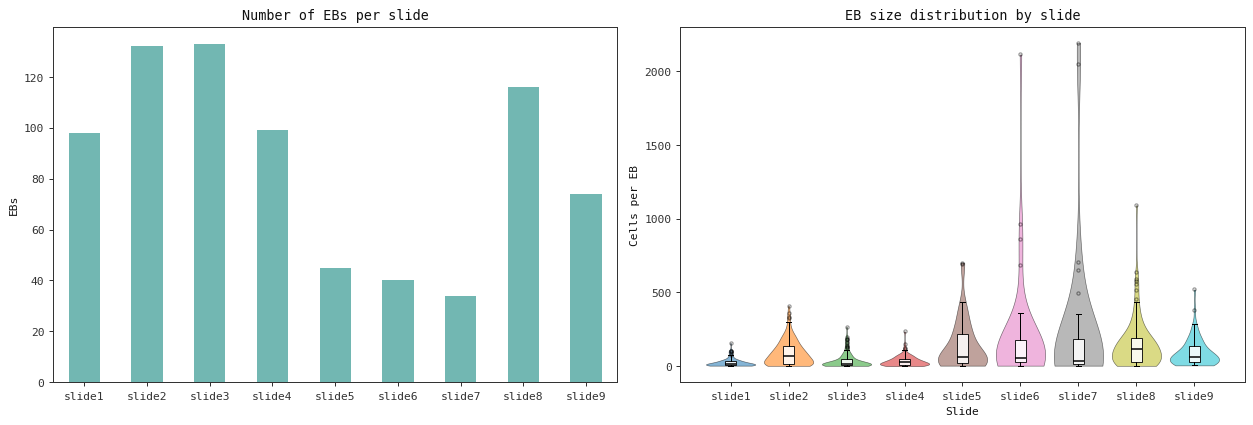

In [4]:
eb_per_slide = obs.groupby('slide')['EB_cluster_manual'].nunique().reindex(SLIDES)
eb_sizes = obs.groupby(['slide','EB_id']).size().reset_index(name='cells_per_EB')
print('EBs per slide:')
display(eb_per_slide.rename('n_EBs').to_frame())
print('Cells per EB distribution by slide:')
eb_size_summary = eb_sizes.groupby('slide')['cells_per_EB'].describe(percentiles=[.1,.25,.5,.75,.9]).reindex(SLIDES)
display(eb_size_summary)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
eb_per_slide.plot.bar(ax=ax[0], color='#72B7B2')
ax[0].set(title='Number of EBs per slide', xlabel='', ylabel='EBs')
ax[0].tick_params(axis='x', rotation=0)

# Each observation is one EB; violin shows the distribution and the inset box shows quartiles/median.
slide_labels = list(SLIDES)
data_by_slide = [eb_sizes.loc[eb_sizes['slide'] == s, 'cells_per_EB'].to_numpy() for s in slide_labels]
positions = np.arange(1, len(slide_labels) + 1)
palette = mpl.colormaps['tab10'].resampled(len(slide_labels))
parts = ax[1].violinplot(data_by_slide, positions=positions, showmeans=False, showmedians=False,
                         showextrema=False, widths=0.85)
for body, color in zip(parts['bodies'], palette.colors):
    body.set_facecolor(color); body.set_edgecolor('black'); body.set_alpha(0.55); body.set_linewidth(0.5)
bp = ax[1].boxplot(data_by_slide, positions=positions, widths=0.18, showfliers=True,
                   patch_artist=True, manage_ticks=False,
                   boxprops=dict(facecolor='white', alpha=0.85, linewidth=0.8),
                   medianprops=dict(color='black', linewidth=1.2),
                   whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                   flierprops=dict(marker='o', markersize=2.5, alpha=0.4))
ax[1].set_xticks(positions, slide_labels)
ax[1].set(title='EB size distribution by slide', xlabel='Slide', ylabel='Cells per EB')
plt.tight_layout(); plt.show()


## 3. Spatial QC

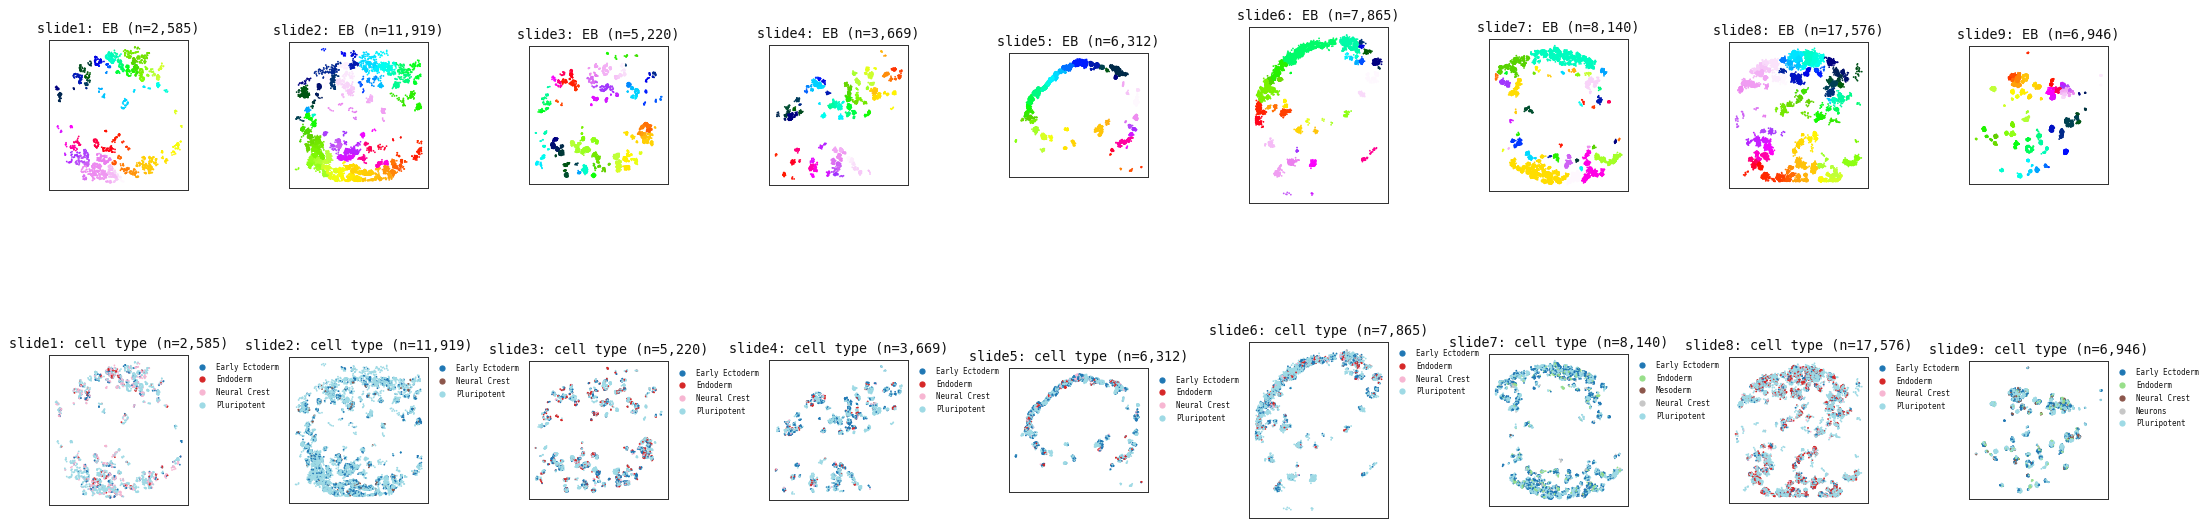

EB colors are slide-specific. Cell-type legends are shown separately for each slide.


In [5]:
def categorical_colors(values, cmap_name='tab20'):
    cats = sorted(pd.Series(values).dropna().astype(str).unique())
    cmap = mpl.colormaps[cmap_name].resampled(max(len(cats), 1))
    lut = {c: cmap(i) for i,c in enumerate(cats)}
    return cats, np.array([lut.get(str(v), (0.7,0.7,0.7,1)) for v in values])

fig, axes = plt.subplots(2, len(SLIDES), figsize=(24, 7), constrained_layout=True)
for j, slide in enumerate(SLIDES):
    sdf = obs.loc[obs.slide == slide]
    xy = spatial[slide]
    for i, col in enumerate(['EB_cluster_manual','cell_type']):
        cats, colors = categorical_colors(sdf[col].values, 'gist_ncar' if i==0 else 'tab20')
        axes[i,j].scatter(xy[:,0], xy[:,1], c=colors, s=2, linewidths=0, rasterized=True)
        axes[i,j].set_title(f'{slide}: {"EB" if i==0 else "cell type"} (n={len(sdf):,})')
        axes[i,j].set_aspect('equal'); axes[i,j].invert_yaxis(); axes[i,j].set_xticks([]); axes[i,j].set_yticks([])
        if i == 1 and len(cats) <= 15:
            handles=[mpl.lines.Line2D([],[],marker='o',ls='',ms=4,color=mpl.colormaps['tab20'].resampled(len(cats))(k),label=c) for k,c in enumerate(cats)]
            axes[i,j].legend(handles=handles, fontsize=6, frameon=False, loc='upper left', bbox_to_anchor=(1.0,1.0))
plt.show()
print('EB colors are slide-specific. Cell-type legends are shown separately for each slide.')

## 4. sgRNA and target-gene summary

Unique individual sgRNAs: 1,262
Unique target genes: 299
Cells per sgRNA summary:


,cells
count,1262.000000
mean,65.840729
std,1085.798298
min,1.000000
10%,2.000000
25%,6.000000
50%,18.000000
75%,46.000000
90%,84.900000
max,38563.000000


Cells per target summary:


,cells
count,299.000000
mean,277.698997
std,2224.795354
min,2.000000
10%,34.800000
25%,70.500000
50%,127.000000
75%,194.500000
90%,295.800000
max,38563.000000


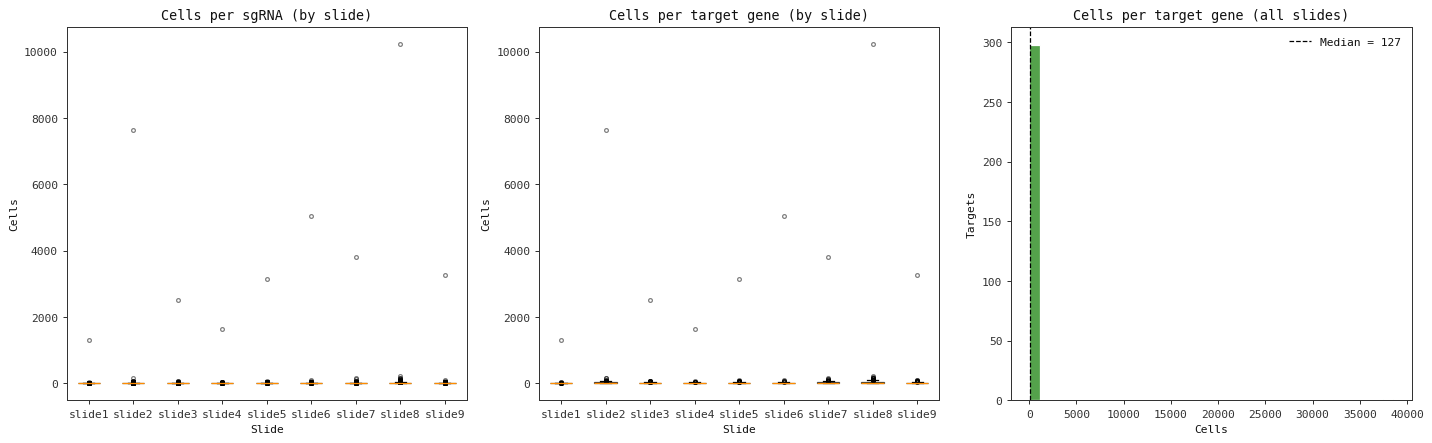

In [6]:
guide_records=[]
for idx, row in obs[['slide','guide_list','target_list']].iterrows():
    for g in row.guide_list: guide_records.append((idx,row.slide,g,guide_target(g)))
guide_long=pd.DataFrame(guide_records,columns=['cell_index','slide','guide','target'])
guide_counts=guide_long.groupby('guide').cell_index.nunique().sort_values(ascending=False)
target_counts=guide_long.groupby('target').cell_index.nunique().sort_values(ascending=False)
print(f'Unique individual sgRNAs: {guide_counts.size:,}')
print(f'Unique target genes: {target_counts.size:,}')
print('Cells per sgRNA summary:')
display(guide_counts.describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('cells'))
print('Cells per target summary:')
display(target_counts.describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('cells'))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot: cells per sgRNA (by slide)
guide_per_slide = guide_long.groupby(['slide','guide']).cell_index.nunique().reset_index(name='cells')
slide_labels = sorted(guide_per_slide['slide'].unique())
data_guides = [guide_per_slide[guide_per_slide['slide']==s]['cells'].values for s in slide_labels]
bp1 = ax[0].boxplot(data_guides, tick_labels=slide_labels, patch_artist=True, showfliers=True,
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
colors = mpl.colormaps['tab10'].resampled(len(slide_labels)).colors
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax[0].set(title='Cells per sgRNA (by slide)', xlabel='Slide', ylabel='Cells')

# Boxplot: cells per target gene (by slide)
target_per_slide = guide_long.groupby(['slide','target']).cell_index.nunique().reset_index(name='cells')
data_targets = [target_per_slide[target_per_slide['slide']==s]['cells'].values for s in slide_labels]
bp2 = ax[1].boxplot(data_targets, tick_labels=slide_labels, patch_artist=True, showfliers=True,
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax[1].set(title='Cells per target gene (by slide)', xlabel='Slide', ylabel='Cells')

# Histogram: cells per target gene (all slides pooled)
ax[2].hist(target_counts.values, bins='auto', color='#54A24B', edgecolor='white')
ax[2].axvline(target_counts.median(), color='black', ls='--', lw=1,
              label=f'Median = {target_counts.median():.0f}')
ax[2].set(title='Cells per target gene (all slides)', xlabel='Cells', ylabel='Targets')
ax[2].legend(frameon=False)
plt.tight_layout(); plt.show()


## 5. Target-gene knockdown efficiency

In [7]:
# Extract one gene column without loading the full expression matrix.
def expression_vector(slide, gene):
    names = gene_names[slide]
    hits = np.flatnonzero(names == gene)
    if len(hits) == 0: return None
    if len(hits) > 1: print(f'Warning: duplicate gene name {gene} on {slide}; using first')
    j = int(hits[0])
    path = DATA / SLIDES[slide][0]
    with h5py.File(path, 'r') as f:
        X = f['X']; enc = X.attrs.get('encoding-type','')
        if isinstance(enc, bytes): enc=enc.decode()
        shape=tuple(X.attrs['shape'])
        if enc == 'csc_matrix':
            lo,hi=int(X['indptr'][j]),int(X['indptr'][j+1])
            rows=X['indices'][lo:hi]; vals=X['data'][lo:hi]
            out=np.zeros(shape[0],dtype=float); out[rows]=vals
        else:
            mat=read_sparse(X); out=np.asarray(mat[:,j].toarray()).ravel()
    return out

def bh_adjust(p):
    p=np.asarray(p,float); n=len(p); order=np.argsort(p); ranked=p[order]
    adj=np.minimum.accumulate((ranked*n/np.arange(1,n+1))[::-1])[::-1]
    out=np.empty(n); out[order]=np.clip(adj,0,1); return out

MIN_TARGET_CELLS=10
PSEUDOCOUNT=0.01
results=[]
for target,n_target_total in target_counts[target_counts>=MIN_TARGET_CELLS].items():
    plus_all=[]; other_all=[]; slides_used=[]
    for slide in SLIDES:
        expr=expression_vector(slide,target)
        if expr is None: continue
        sdf=obs.loc[obs.slide==slide]
        plus=np.array([target in z for z in sdf.target_list],dtype=bool)
        if plus.any():
            plus_all.append(expr[plus]); other_all.append(expr[~plus]); slides_used.append(slide)
    if not plus_all: continue
    a=np.concatenate(plus_all); b=np.concatenate(other_all)
    # Mann-Whitney/Wilcoxon rank-sum with asymptotic tie correction (scipy implementation).
    u,p=stats.mannwhitneyu(a,b,alternative='two-sided',method='asymptotic')
    mean_a,mean_b=float(a.mean()),float(b.mean())
    log2fc=float(np.log2((mean_a+PSEUDOCOUNT)/(mean_b+PSEUDOCOUNT)))
    rb=float(2*u/(len(a)*len(b))-1)  # rank-biserial correlation; negative indicates lower expression in target+ cells
    results.append(dict(target=target,n_target=len(a),n_other=len(b),mean_target=mean_a,mean_other=mean_b,
                        log2FC=log2fc,percent_change=(2**log2fc-1)*100,U=u,p_value=p,rank_biserial=rb,
                        slides=','.join(slides_used)))
kd=pd.DataFrame(results)
if len(kd):
    kd['q_value_BH']=bh_adjust(kd.p_value.values)
    kd['minus_log10_p']=-np.log10(np.maximum(kd.p_value,np.nextafter(0,1)))
    kd=kd.sort_values('log2FC').reset_index(drop=True)
print(f'Evaluable targets (>= {MIN_TARGET_CELLS} target-positive cells and expression feature present): {len(kd):,}')
print(f'Median log2 fold change: {kd.log2FC.median():.3f}')
print(f'Median signed expression change: {kd.percent_change.median():.1f}%')
print(f"Targets with lower expression and BH q<0.05: {((kd.log2FC<0)&(kd.q_value_BH<.05)).sum():,}")
display(kd.head(20)[['target','n_target','mean_target','mean_other','log2FC','percent_change','rank_biserial','p_value','q_value_BH','slides']])

Evaluable targets (>= 10 target-positive cells and expression feature present): 291
Median log2 fold change: -0.330
Median signed expression change: -20.5%
Targets with lower expression and BH q<0.05: 13


,target,n_target,mean_target,mean_other,log2FC,percent_change,rank_biserial,p_value,q_value_BH,slides
0,EPHB4,26,0.004719,0.091895,-2.791289,-85.554315,-0.129348,0.074785,0.356763,"slide2,slide4,slide5,slide7,slide8"
1,MAP2K3,46,0.000000,0.025203,-1.815695,-71.593267,-0.043784,0.146843,0.503761,"slide1,slide2,slide3,slide4,slide5,slide6,slid..."
2,CAMK1,13,0.000000,0.017906,-1.480559,-64.164996,-0.034976,0.492576,0.816937,"slide6,slide7,slide8,slide9"
3,EEF2K,71,0.014247,0.056239,-1.449897,-63.395238,-0.027626,0.447402,0.776120,"slide1,slide2,slide3,slide4,slide5,slide6,slid..."
4,TBK1,46,0.032891,0.105802,-1.432918,-62.961896,-0.104042,0.070580,0.348116,"slide1,slide2,slide3,slide4,slide5,slide6,slid..."
5,DYRK4,70,0.000000,0.016279,-1.393908,-61.946726,-0.030700,0.136565,0.492755,"slide1,slide2,slide3,slide4,slide5,slide6,slid..."
6,TRIB2,35,0.012112,0.047107,-1.368867,-61.280470,-0.027182,0.555452,0.829700,"slide1,slide2,slide4,slide5,slide6,slide7,slid..."
7,STK38,60,0.045878,0.131912,-1.344637,-60.624705,-0.105232,0.052568,0.299945,"slide2,slide3,slide4,slide5,slide6,slide7,slid..."
8,KIT,82,0.015919,0.054683,-1.319403,-59.929929,-0.015122,0.638765,0.880604,"slide1,slide2,slide3,slide4,slide5,slide6,slid..."
9,BCKDK,121,0.007648,0.033296,-1.294726,-59.238634,-0.020175,0.317678,0.681839,"slide1,slide2,slide3,slide4,slide5,slide6,slid..."


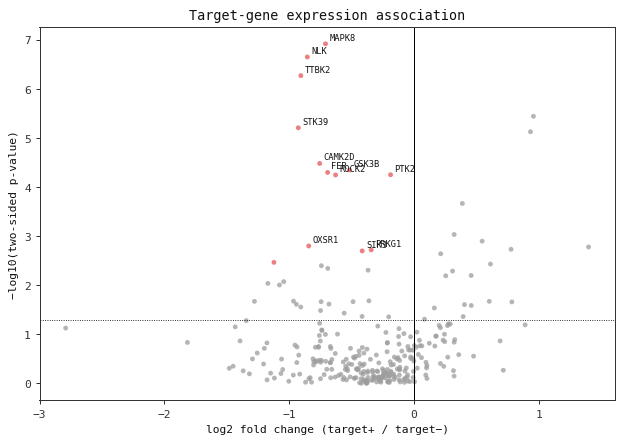

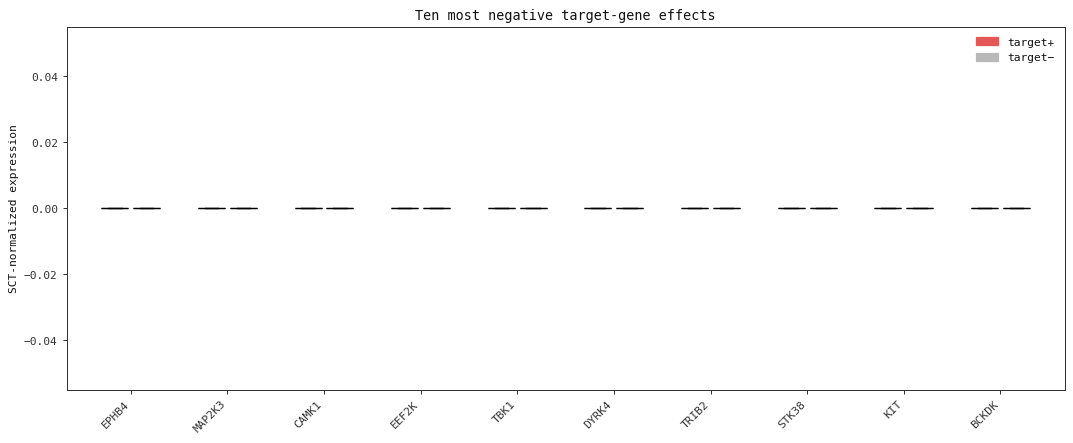

In [8]:
fig,ax=plt.subplots(figsize=(7,5))
sig=(kd.q_value_BH<.05)&(kd.log2FC<0)
ax.scatter(kd.log2FC,kd.minus_log10_p,s=15,c=np.where(sig,'#E45756','#9D9D9D'),alpha=.75,linewidth=0)
ax.axvline(0,color='black',lw=.8); ax.axhline(-np.log10(.05),color='black',lw=.7,ls=':')
# Label strongest evidence among downregulated hits, balancing p-value and effect.
to_label=kd.loc[kd.log2FC<0].sort_values(['q_value_BH','log2FC']).head(12)
for _,r in to_label.iterrows(): ax.annotate(r.target,(r.log2FC,r.minus_log10_p),fontsize=7,xytext=(3,3),textcoords='offset points')
ax.set(xlabel='log2 fold change (target+ / target−)',ylabel='−log10(two-sided p-value)',title='Target-gene expression association')
plt.tight_layout(); plt.show()

# Top 10 most negative estimated effects; controls are plotted without subsampling.
top10=kd.head(10).target.tolist()
boxdata=[]; labels=[]; positions=[]; pos=1
for target in top10:
    a_all=[]; b_all=[]
    for slide in SLIDES:
        expr=expression_vector(slide,target)
        if expr is None: continue
        sdf=obs.loc[obs.slide==slide]
        plus=np.array([target in z for z in sdf.target_list],bool)
        if plus.any(): a_all.append(expr[plus]); b_all.append(expr[~plus])
    a=np.concatenate(a_all); b=np.concatenate(b_all)
    boxdata.extend([a,b]); positions.extend([pos,pos+0.33]); labels.append(target); pos+=1
fig,ax=plt.subplots(figsize=(12,5))
bp=ax.boxplot(boxdata,positions=positions,widths=.28,showfliers=False,patch_artist=True,medianprops={'color':'black'})
for i,p in enumerate(bp['boxes']): p.set_facecolor('#E45756' if i%2==0 else '#B8B8B8')
ax.set_xticks(np.arange(1,len(top10)+1)+.165,top10,rotation=45,ha='right')
ax.set_ylabel('SCT-normalized expression'); ax.set_title('Ten most negative target-gene effects')
ax.legend(handles=[mpl.patches.Patch(color='#E45756',label='target+'),mpl.patches.Patch(color='#B8B8B8',label='target−')],frameon=False)
plt.tight_layout(); plt.show()

### Interpretation caution

A negative log2 fold change is consistent with knockdown, but not sufficient to establish it. The comparison is not randomized at the analysis level, has no NTC group, and does not account for EB-level dependence or cell-state imbalance. The reported rank-biserial correlation is an effect size for distributional separation; negative values indicate lower ranks in target-positive cells. BH-adjusted q-values control false discovery rate across the evaluated targets under the standard dependence assumptions.


## 6. sgRNA-positive cells and targets across cell types

Perturbation counts and fractions by cell type:


is_perturbed_any,sgRNA−,sgRNA+,sgRNA−_fraction,sgRNA+_fraction
cell_type,,,,
Early Ectoderm,6237,7456,0.455488,0.544512
Endoderm,3035,4230,0.417756,0.582244
Mesoderm,10,2,0.833333,0.166667
Neural Crest,1666,1576,0.513880,0.486120
Neurons,15,7,0.681818,0.318182
Pluripotent,27600,18398,0.600026,0.399974


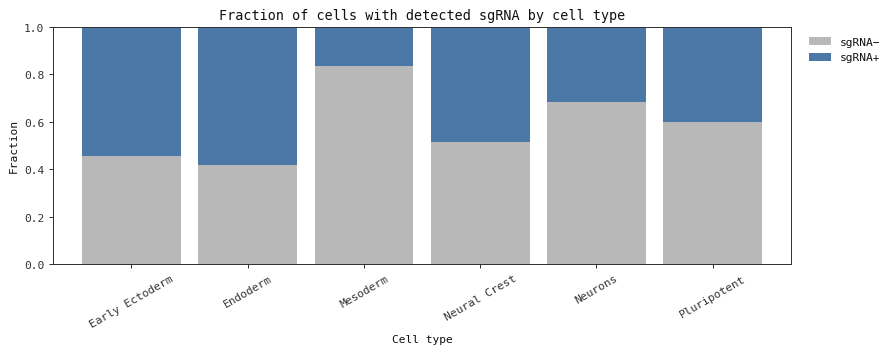

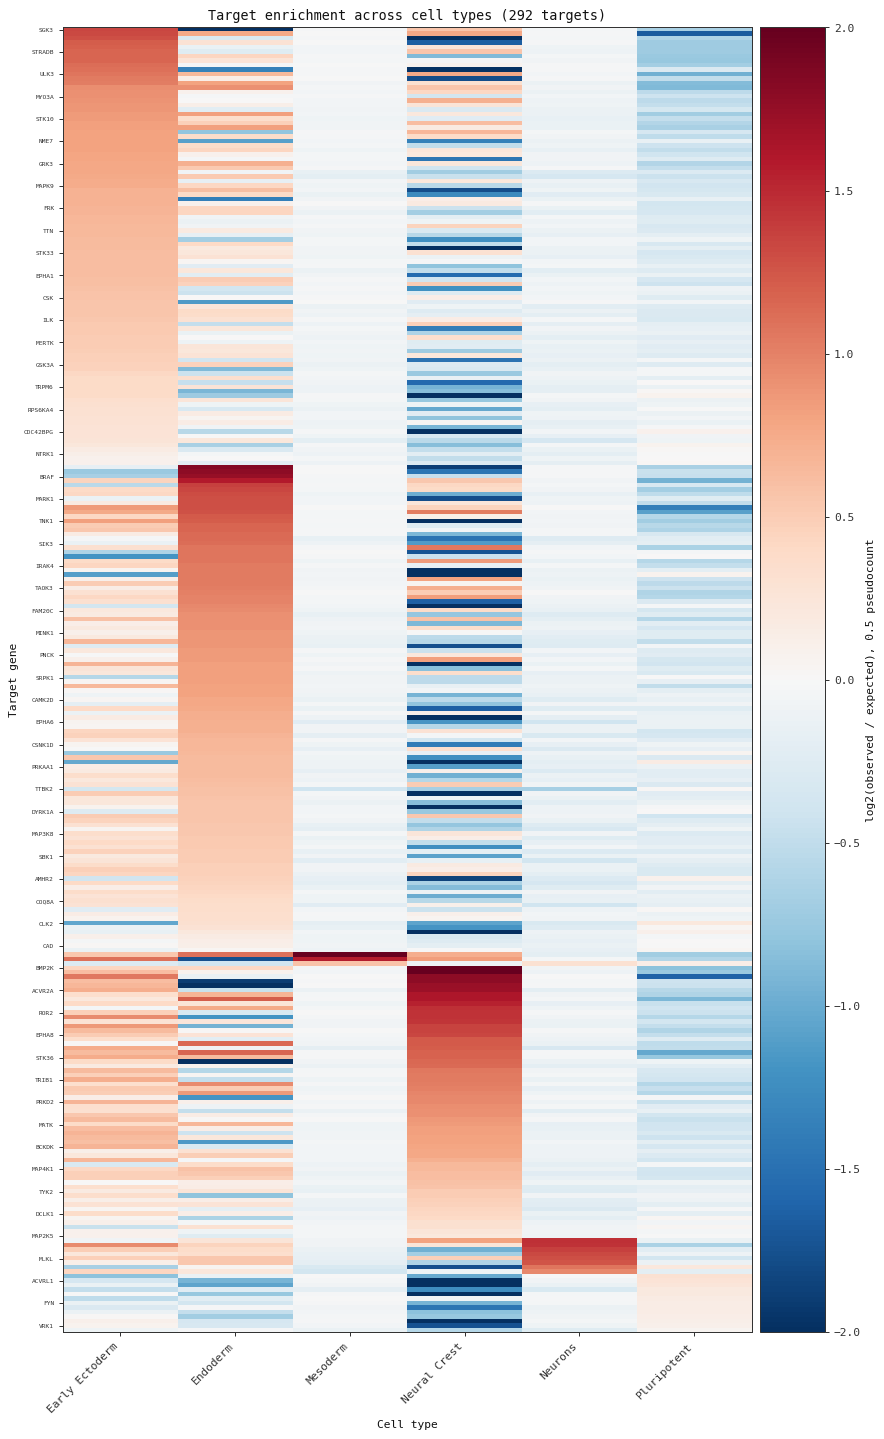

Heatmap count matrix dimensions: (292, 6)
Counts used to calculate enrichment (first 10 rows):


cell_type,Early Ectoderm,Endoderm,Mesoderm,Neural Crest,Neurons,Pluripotent
target,,,,,,
NTC,6237,3035,10,1666,15,27600
TTBK2,143,146,0,27,0,620
ROCK2,223,103,0,37,1,488
PTK2,84,74,0,9,1,518
EPHA6,103,86,0,10,0,307
MAPK8,121,67,0,25,0,292
MAP4K4,106,67,0,19,0,263
MAP3K21,138,62,0,14,0,202
STK39,96,50,0,13,0,254


In [9]:
ct_pert = pd.crosstab(obs.cell_type, obs.is_perturbed_any).rename(columns={False:'sgRNA−',True:'sgRNA+'})
for c in ['sgRNA−','sgRNA+']:
    if c not in ct_pert: ct_pert[c] = 0
ct_frac = ct_pert.div(ct_pert.sum(axis=1), axis=0)
print('Perturbation counts and fractions by cell type:')
display(ct_pert.join(ct_frac.add_suffix('_fraction')))
ax = ct_frac[['sgRNA−','sgRNA+']].plot.bar(stacked=True, figsize=(10,4),
                                            color=['#B8B8B8','#4C78A8'], width=.85)
ax.set(title='Fraction of cells with detected sgRNA by cell type',
       xlabel='Cell type', ylabel='Fraction')
ax.set_ylim(0,1)
ax.tick_params(axis='x', rotation=30)
ax.legend(frameon=False, bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout(); plt.show()

# Target enrichment across cell types
eligible = target_counts[target_counts >= MIN_TARGET_CELLS].index
pairs = []
for _, r in obs[['cell_type','target_list']].iterrows():
    for t in r.target_list:
        if t in eligible: pairs.append((t, r.cell_type))
pairdf = pd.DataFrame(pairs, columns=['target','cell_type'])
counts = pd.crosstab(pairdf.target, pairdf.cell_type).reindex(index=eligible, fill_value=0)
ct_totals = obs.cell_type.value_counts().reindex(counts.columns).values
row_totals = counts.sum(axis=1).values
expected = np.outer(row_totals, ct_totals) / len(obs)
enrichment = np.log2((counts.values + 0.5) / (expected + 0.5))
enrich_df = pd.DataFrame(enrichment, index=counts.index, columns=counts.columns)
order = np.lexsort((-enrich_df.max(axis=1).values, enrich_df.values.argmax(axis=1)))
enrich_df = enrich_df.iloc[order]
fig_h = max(7, min(18, 0.055 * len(enrich_df)))
fig, ax = plt.subplots(figsize=(10, fig_h))
im = ax.imshow(enrich_df.values, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2, interpolation='nearest')
ax.set_xticks(range(len(enrich_df.columns)), enrich_df.columns, rotation=45, ha='right')
if len(enrich_df) <= 80:
    ax.set_yticks(range(len(enrich_df.index)), enrich_df.index, fontsize=6)
else:
    step = max(1, len(enrich_df) // 50)
    ticks = np.arange(0, len(enrich_df), step)
    ax.set_yticks(ticks, enrich_df.index[ticks], fontsize=5)
ax.set(title=f'Target enrichment across cell types ({len(enrich_df)} targets)',
       xlabel='Cell type', ylabel='Target gene')
cb = fig.colorbar(im, ax=ax, pad=.01)
cb.set_label('log2(observed / expected), 0.5 pseudocount')
plt.tight_layout(); plt.show()
print('Heatmap count matrix dimensions:', counts.shape)
print('Counts used to calculate enrichment (first 10 rows):')
display(counts.head(10))


## Reproducibility summary

In [10]:
print(f'Total cells: {len(obs):,}')
print(f"Cells flagged sgRNA+: {obs.is_perturbed_any.sum():,} ({obs.is_perturbed_any.mean():.1%})")
print(f'Unique EBs (slide-qualified): {obs.EB_id.nunique():,}')
print(f'Unique sgRNAs: {guide_counts.size:,}; targets: {target_counts.size:,}')
print(f'Evaluable knockdown targets: {len(kd):,}')
print(f'Median target+/target− expression change: {kd.percent_change.median():.1f}%')
print()
print('Software:')
print('Python',sys.version.split()[0])
print('h5py',h5py.__version__,'numpy',np.__version__,'pandas',pd.__version__,'scipy',__import__('scipy').__version__,'matplotlib',mpl.__version__)

Total cells: 70,232
Cells flagged sgRNA+: 31,669 (45.1%)
Unique EBs (slide-qualified): 774
Unique sgRNAs: 1,262; targets: 299
Evaluable knockdown targets: 291
Median target+/target− expression change: -20.5%

Software:
Python 3.13.7
h5py 3.16.0 numpy 2.4.3 pandas 2.3.3 scipy 1.17.1 matplotlib 3.10.8
